# Part II - (Presentation Title)
## by Salsabeel Dwaikat

## Investigation Overview


> This presentation explores patterns in bike-sharing usage with a focus on how trip duration, time of usage, and user characteristics (such as user type, age, and gender) influence riding behavior.

> The goal is to identify meaningful behavioral differences between Subscribers and Customers, as well as uncover temporal trends across days of the week and hours of the day. These insights can help better understand commuting patterns versus leisure usage and support data-driven decision-making for service optimization.



## Dataset Overview and Executive Summary

> The dataset contains trip-level records from a bike-sharing system, including trip duration, user type (Subscriber or Customer), member demographics, and timestamps of rides.

### Key Insights:

* Subscribers tend to have shorter and more consistent trip durations compared to Customers.
* Customers generally take longer trips, suggesting more leisure-oriented usage.
* Peak usage occurs during typical commuting hours (morning and evening) on weekdays.
* Weekend usage shows a different pattern, with more evenly distributed ride activity throughout the day.
* Age has a weak but noticeable relationship with trip duration, with younger users showing slightly more variability.


In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

In [2]:
# Load dataset
df = pd.read_csv('201902-fordgobike-tripdata.csv')

# Convert duration to minutes
df['duration_min'] = df['duration_sec'] / 60

# Convert time columns
df['start_time'] = pd.to_datetime(df['start_time'])

# Extract useful features
df['hour'] = df['start_time'].dt.hour
df['day_of_week'] = df['start_time'].dt.day_name()

# Clean ages
df['member_age'] = 2019 - df['member_birth_year']
df = df[(df['member_age'] >= 18) & (df['member_age'] <= 80)]

## Visualization 1: Trip Duration by User Type

This visualization compares trip duration distributions between Subscribers and Customers.

Subscribers are expected to have shorter trips due to routine commuting, while Customers may have longer, leisure-oriented rides.

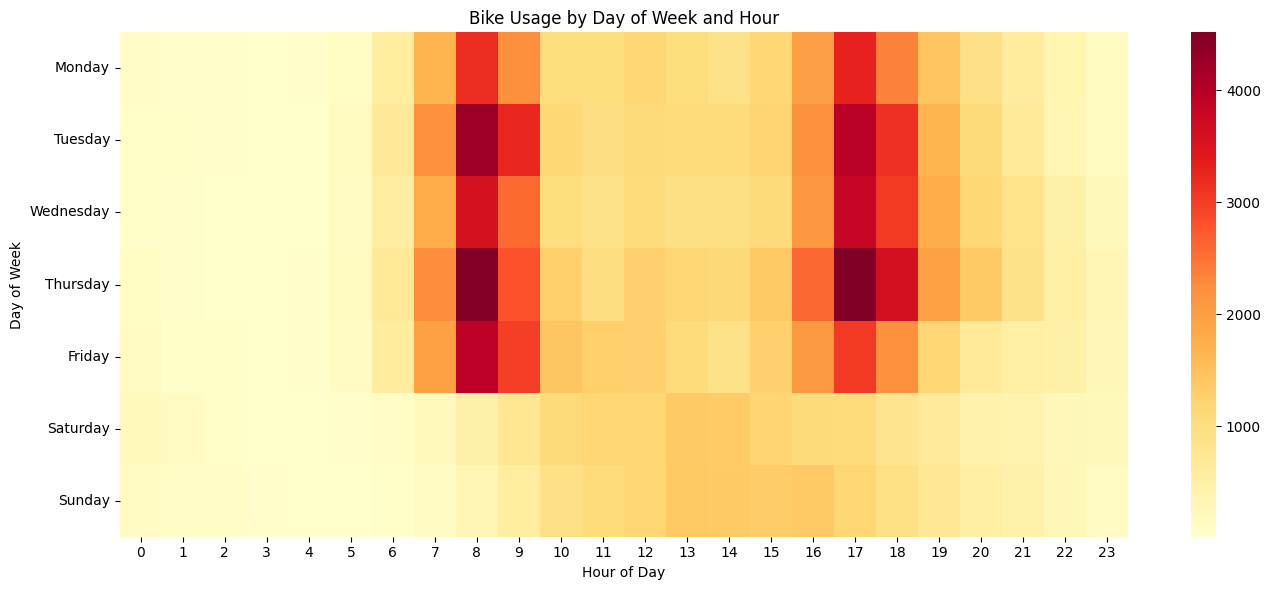

In [3]:
plt.figure(figsize=(14,6))

pivot = df.groupby(['day_of_week', 'hour'], observed=True).size().unstack(fill_value=0)

# Order days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(day_order)

sns.heatmap(pivot, cmap='YlOrRd')

plt.title('Bike Usage by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.tight_layout()
plt.show()

Bike usage shows strong peaks during weekday commuting hours, especially around 8 AM and 5–6 PM. 

This pattern indicates that most users rely on the service for daily commuting. Weekend usage is more evenly distributed throughout the day, suggesting more leisure-oriented trips.

## Visualization 2: Bike Usage by Time (Day & Hour)

This heatmap shows when bikes are most frequently used throughout the week.

It helps identify peak demand periods and distinguish between commuting and leisure usage patterns.

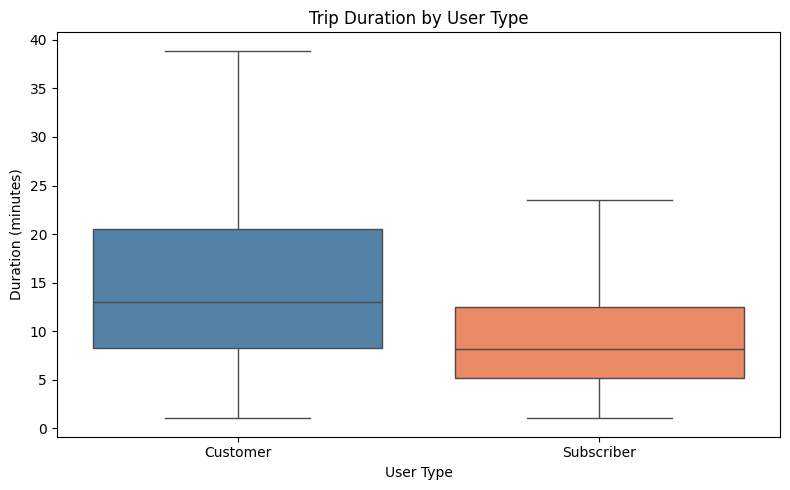

In [5]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='user_type',
    y='duration_min',
    hue='user_type',
    palette=['steelblue', 'coral'],
    legend=False,
    showfliers=False
)

plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Duration (minutes)')

plt.tight_layout()
plt.show()

Customers tend to have longer trip durations compared to Subscribers. 

Subscribers show more consistent and shorter trips, which aligns with commuting behavior. In contrast, Customers likely use the service for casual or recreational purposes, resulting in longer ride durations.

## Visualization 3: Age vs Trip Duration by User Type

This scatter plot examines how user age relates to trip duration, with color representing user type.

It helps identify whether younger or older users tend to take longer trips and whether behavior differs between Subscribers and Customers.

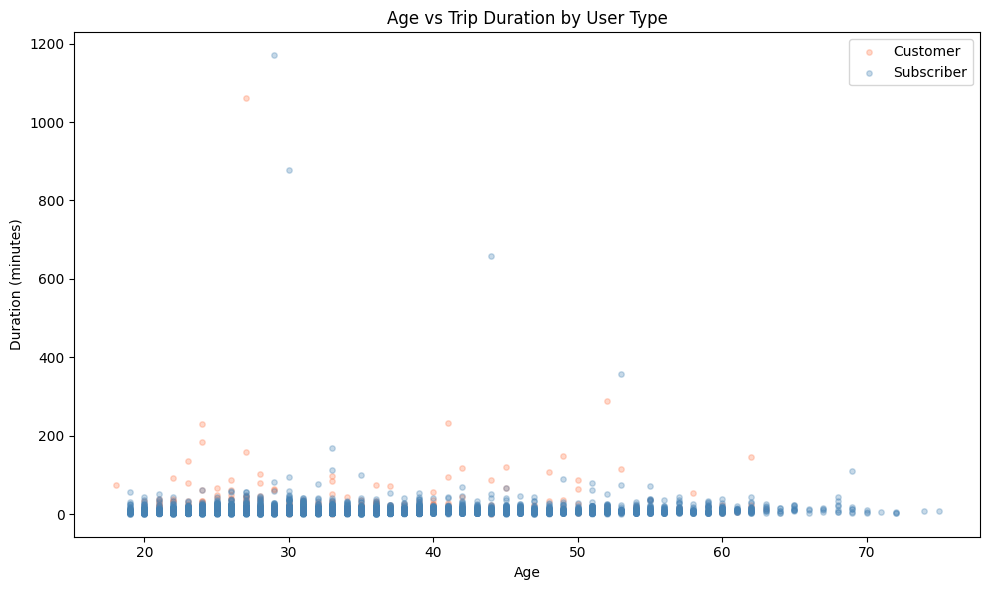

In [6]:
sample = df.sample(n=6000, random_state=42)

plt.figure(figsize=(10,6))

colors = {'Subscriber': 'steelblue', 'Customer': 'coral'}

for utype, group in sample.groupby('user_type', observed=True):
    plt.scatter(group['member_age'], group['duration_min'],
                alpha=0.3, s=15, color=colors[utype], label=utype)

plt.title('Age vs Trip Duration by User Type')
plt.xlabel('Age')
plt.ylabel('Duration (minutes)')
plt.legend()

plt.tight_layout()
plt.show()

There is a weak negative relationship between age and trip duration, where younger users tend to take slightly longer trips.

The distinction between user types remains clear, with Customers generally having longer durations across all age groups.

## Visualization 4: Mean Trip Duration by Day of Week and User Type

This chart compares how average trip duration varies across the week for different user types.

It helps determine whether the gap between Subscribers and Customers changes depending on the day.

<Figure size 1000x500 with 0 Axes>

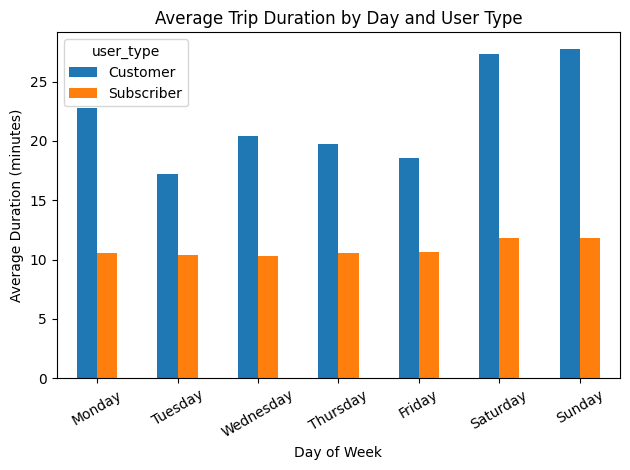

In [8]:
plt.figure(figsize=(10,5))

pivot = df.groupby(['day_of_week', 'user_type'], observed=True)['duration_min'].mean().unstack()

pivot = pivot.reindex(day_order)

pivot.plot(kind='bar')

plt.title('Average Trip Duration by Day and User Type')
plt.xlabel('Day of Week')
plt.ylabel('Average Duration (minutes)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()## Visualization 4: Mean Trip Duration by Day of Week and User Type

This chart compares how average trip duration varies across the week for different user types.

It helps determine whether the gap between Subscribers and Customers changes depending on the day.

Customers consistently have longer trips across all days, with slightly higher durations on weekends. Subscribers maintain relatively stable durations throughout the week, reinforcing their commuting usage pattern.

### Submission
If you are using classroom workspace, you can choose from the following two ways of submission:

1. **Submit from the workspace**. Make sure you have removed the example project from the /home/workspace directory. You must submit the following files:
   - Part_I_notebook.ipynb
   - Part_I_notebook.html or pdf
   - Part_II_notebook.ipynb
   - Part_II_notebook.html or pdf


2. **Submit a zip file on the last page of this project lesson**. In this case, open the Jupyter terminal and run the command below to generate a ZIP file. 
```bash
zip -r my_project.zip .
```
The command abobve will ZIP every file present in your /home/workspace directory. Next, you can download the zip to your local, and follow the instructions on the last page of this project lesson.


In [9]:
!jupyter nbconvert --to notebook --output backup_notebook.ipynb "Part_II_explanatory_template.ipynb"

[NbConvertApp] Converting notebook Part_II_explanatory_template.ipynb to notebook
[NbConvertApp] Writing 183860 bytes to backup_notebook.ipynb


In [10]:
zip -r my_project.zip .

SyntaxError: invalid syntax (1840645796.py, line 1)